In [3]:
import os
import glob
import pandas as pd

# ---------- Path configuration ----------
input_dir = r"C:\Users\*****\Desktop\Results\Extreme_Climate_Extraction"
output_file = os.path.join(input_dir, r"C:\Users\*****\Desktop\Results\Figure3\type_annual_mean_1980_2020.csv")

# Year range to calculate
years = [str(y) for y in range(1980, 2021)]  # 1980~2020 as string column names

# Specify the indicator files to process (6 files)
indicator_files = [
    "CDD_1980_2025_extracted.csv",
    "R95p_1980_2025_extracted.csv",
    "RX1day_1980_2025_extracted.csv",
    "RX5day_1980_2025_extracted.csv",
    "TX90p_1980_2025_extracted.csv",
    "TXx_1980_2025_extracted.csv"
]

# ---------- Process each file ----------
all_results = {}  # Store annual mean values by type for each indicator

for fname in indicator_files:
    file_path = os.path.join(input_dir, fname)
    if not os.path.exists(file_path):
        print(f"Warning: File {fname} does not exist, skipping")
        continue

    # Read file (try utf-8 first, fallback to gbk on failure)
    try:
        df = pd.read_csv(file_path, encoding='utf-8')
    except UnicodeDecodeError:
        df = pd.read_csv(file_path, encoding='gbk')

    # Ensure the Type column exists (usually named "Type")
    if "Type" not in df.columns:
        print(f"File {fname} missing Type column, skipping")
        continue

    # Extract indicator name (take the part before the first underscore in the filename)
    indicator_name = fname.split('_')[0]  # e.g., CDD, R95p ...

    # Keep only existing year columns
    existing_years = [y for y in years if y in df.columns]
    if not existing_years:
        print(f"File {fname} has no columns for 1980-2020, skipping")
        continue

    # Group by Type and calculate the annual mean for each type
    grouped = df.groupby("Type")[existing_years].mean()

    # Store in results dictionary
    for ty, row in grouped.iterrows():
        # Composite key: (Type, Indicator)
        all_results[(ty, indicator_name)] = row

# ---------- Convert results to a tidy table ----------
if not all_results:
    print("No results calculated. Please check the data.")
else:
    # Reorganize: use Type and Indicator as row indices, years as columns
    records = []
    for (ty, ind), series in all_results.items():
        record = {"Type": ty, "Indicator": ind}
        record.update(series.to_dict())
        records.append(record)

    result_df = pd.DataFrame(records)
    # Sort
    result_df = result_df.sort_values(["Type", "Indicator"]).reset_index(drop=True)

    # Save
    result_df.to_csv(output_file, index=False, encoding='utf-8-sig')
    print(f"Results saved to: {output_file}")

    # Optional: print a preview of the first few rows
    print("\nPreview (first 5 rows):")
    print(result_df.head())

结果已保存至: C:\Users\28550\Desktop\Results\Figure3\type_annual_mean_1980_2020.csv

预览（前5行）:
   Type Indicator        1980        1981        1982        1983        1984  \
0  CAPS       CDD   23.095238   21.857143   17.380952   31.428571   23.952381   
1  CAPS      R95p  426.247620  317.152374  375.523808  536.719049  369.304754   
2  CAPS    RX1day   69.976190   73.890476   77.990476   84.376190   81.119048   
3  CAPS    RX5day  151.452381  150.819046  164.657143  172.776193  144.223809   
4  CAPS     TX90p   10.122300    8.532290    6.692759    9.810828    6.739526   

         1985        1986        1987  ...        2011        2012  \
0   17.523810   23.095238   27.095238  ...   20.666667   21.428571   
1  340.757147  369.347619  375.861905  ...  278.200000  337.066666   
2   74.052381   74.880952   70.966667  ...   70.642857   81.695238   
3  134.823811  133.980952  144.452379  ...  148.852382  152.966666   
4    7.697325    7.788650   15.029354  ...   16.568819    8.821233   

    

In [4]:
import pandas as pd
import numpy as np
import pymannkendall as mk
import os

# ===================== User-defined year range =====================
start_year = 1980   # Start year
end_year   = 2020   # End year (inclusive)

# ===================== Read data =====================
file_path = r"C:\Users\*****\Desktop\Results\Figure3\type_annual_mean_1980_2020.csv"
df = pd.read_csv(file_path, encoding='utf-8')

# Generate and filter year columns
year_cols = [str(y) for y in range(start_year, end_year + 1)]
# Keep only columns that actually exist in the file (prevent errors due to missing years)
year_cols = [col for col in year_cols if col in df.columns]

if not year_cols:
    raise ValueError(f"No columns found for {start_year}-{end_year} in the file. Please check the year range or data file!")

print(f"Analysis will be performed on data from {start_year} to {end_year} ({len(year_cols)} years total).")

# ===================== Row-by-row testing =====================
results = []
for idx, row in df.iterrows():
    type_name = row['Type']
    indicator = row['Indicator']
    # Extract the time series for the corresponding years
    values = pd.to_numeric(row[year_cols], errors='coerce').values
    # Remove missing values
    values = values[~np.isnan(values)]

    if len(values) < 3:
        print(f"Skipping {type_name} - {indicator}, insufficient valid data points ({len(values)})")
        continue

    # Perform Mann-Kendall test + Sen's slope estimation using pymannkendall
    res = mk.original_test(values, alpha=0.05)

    results.append({
        'Type': type_name,
        'Indicator': indicator,
        'Trend': res.trend,                # 'increasing' / 'decreasing' / 'no trend'
        'p_value': res.p,
        'z_score': res.z,
        'Sen_slope': res.slope,
        'Intercept': res.intercept
    })

# ===================== Save results =====================
result_df = pd.DataFrame(results)
print("\n===== Mann-Kendall + Sen's Slope Test Results (pymannkendall) =====")
print(result_df.to_string(index=False))

output_path = os.path.join(os.path.dirname(file_path), f"MK_Sen_results_{start_year}_{end_year}.csv")
result_df.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"\nResults saved to: {output_path}")

将对 1980 年至 2020 年（共 41 年）的数据进行分析。

===== Mann-Kendall + Sen 斜率检验结果（pymannkendall）=====
 Type Indicator      Trend      p_value   z_score  Sen_slope  Intercept
 CAPS       CDD   no trend 3.869163e-01 -0.865223  -0.050970  24.019400
 CAPS      R95p   no trend 7.055328e-02 -1.808342  -1.807181 419.315040
 CAPS    RX1day   no trend 6.777161e-01 -0.415582  -0.039909  78.788662
 CAPS    RX5day   no trend 4.251795e-01 -0.797468  -0.161126 156.189196
 CAPS     TX90p increasing 1.292099e-06  4.840965   0.267449   8.610568
 CAPS       TXx increasing 2.691890e-02  2.212692   0.021704  32.882024
CMHFS       CDD   no trend 8.927586e-01  0.134814   0.005199  25.850564
CMHFS      R95p   no trend 7.783064e-02 -1.763414  -1.576273 327.593636
CMHFS    RX1day   no trend 1.964705e-01 -1.291673  -0.152763  68.541632
CMHFS    RX5day   no trend 8.570791e-02 -1.718487  -0.468168 138.627006
CMHFS     TX90p increasing 4.071072e-07  5.065604   0.266088   9.435410
CMHFS       TXx increasing 3.753994e-05  4.122121

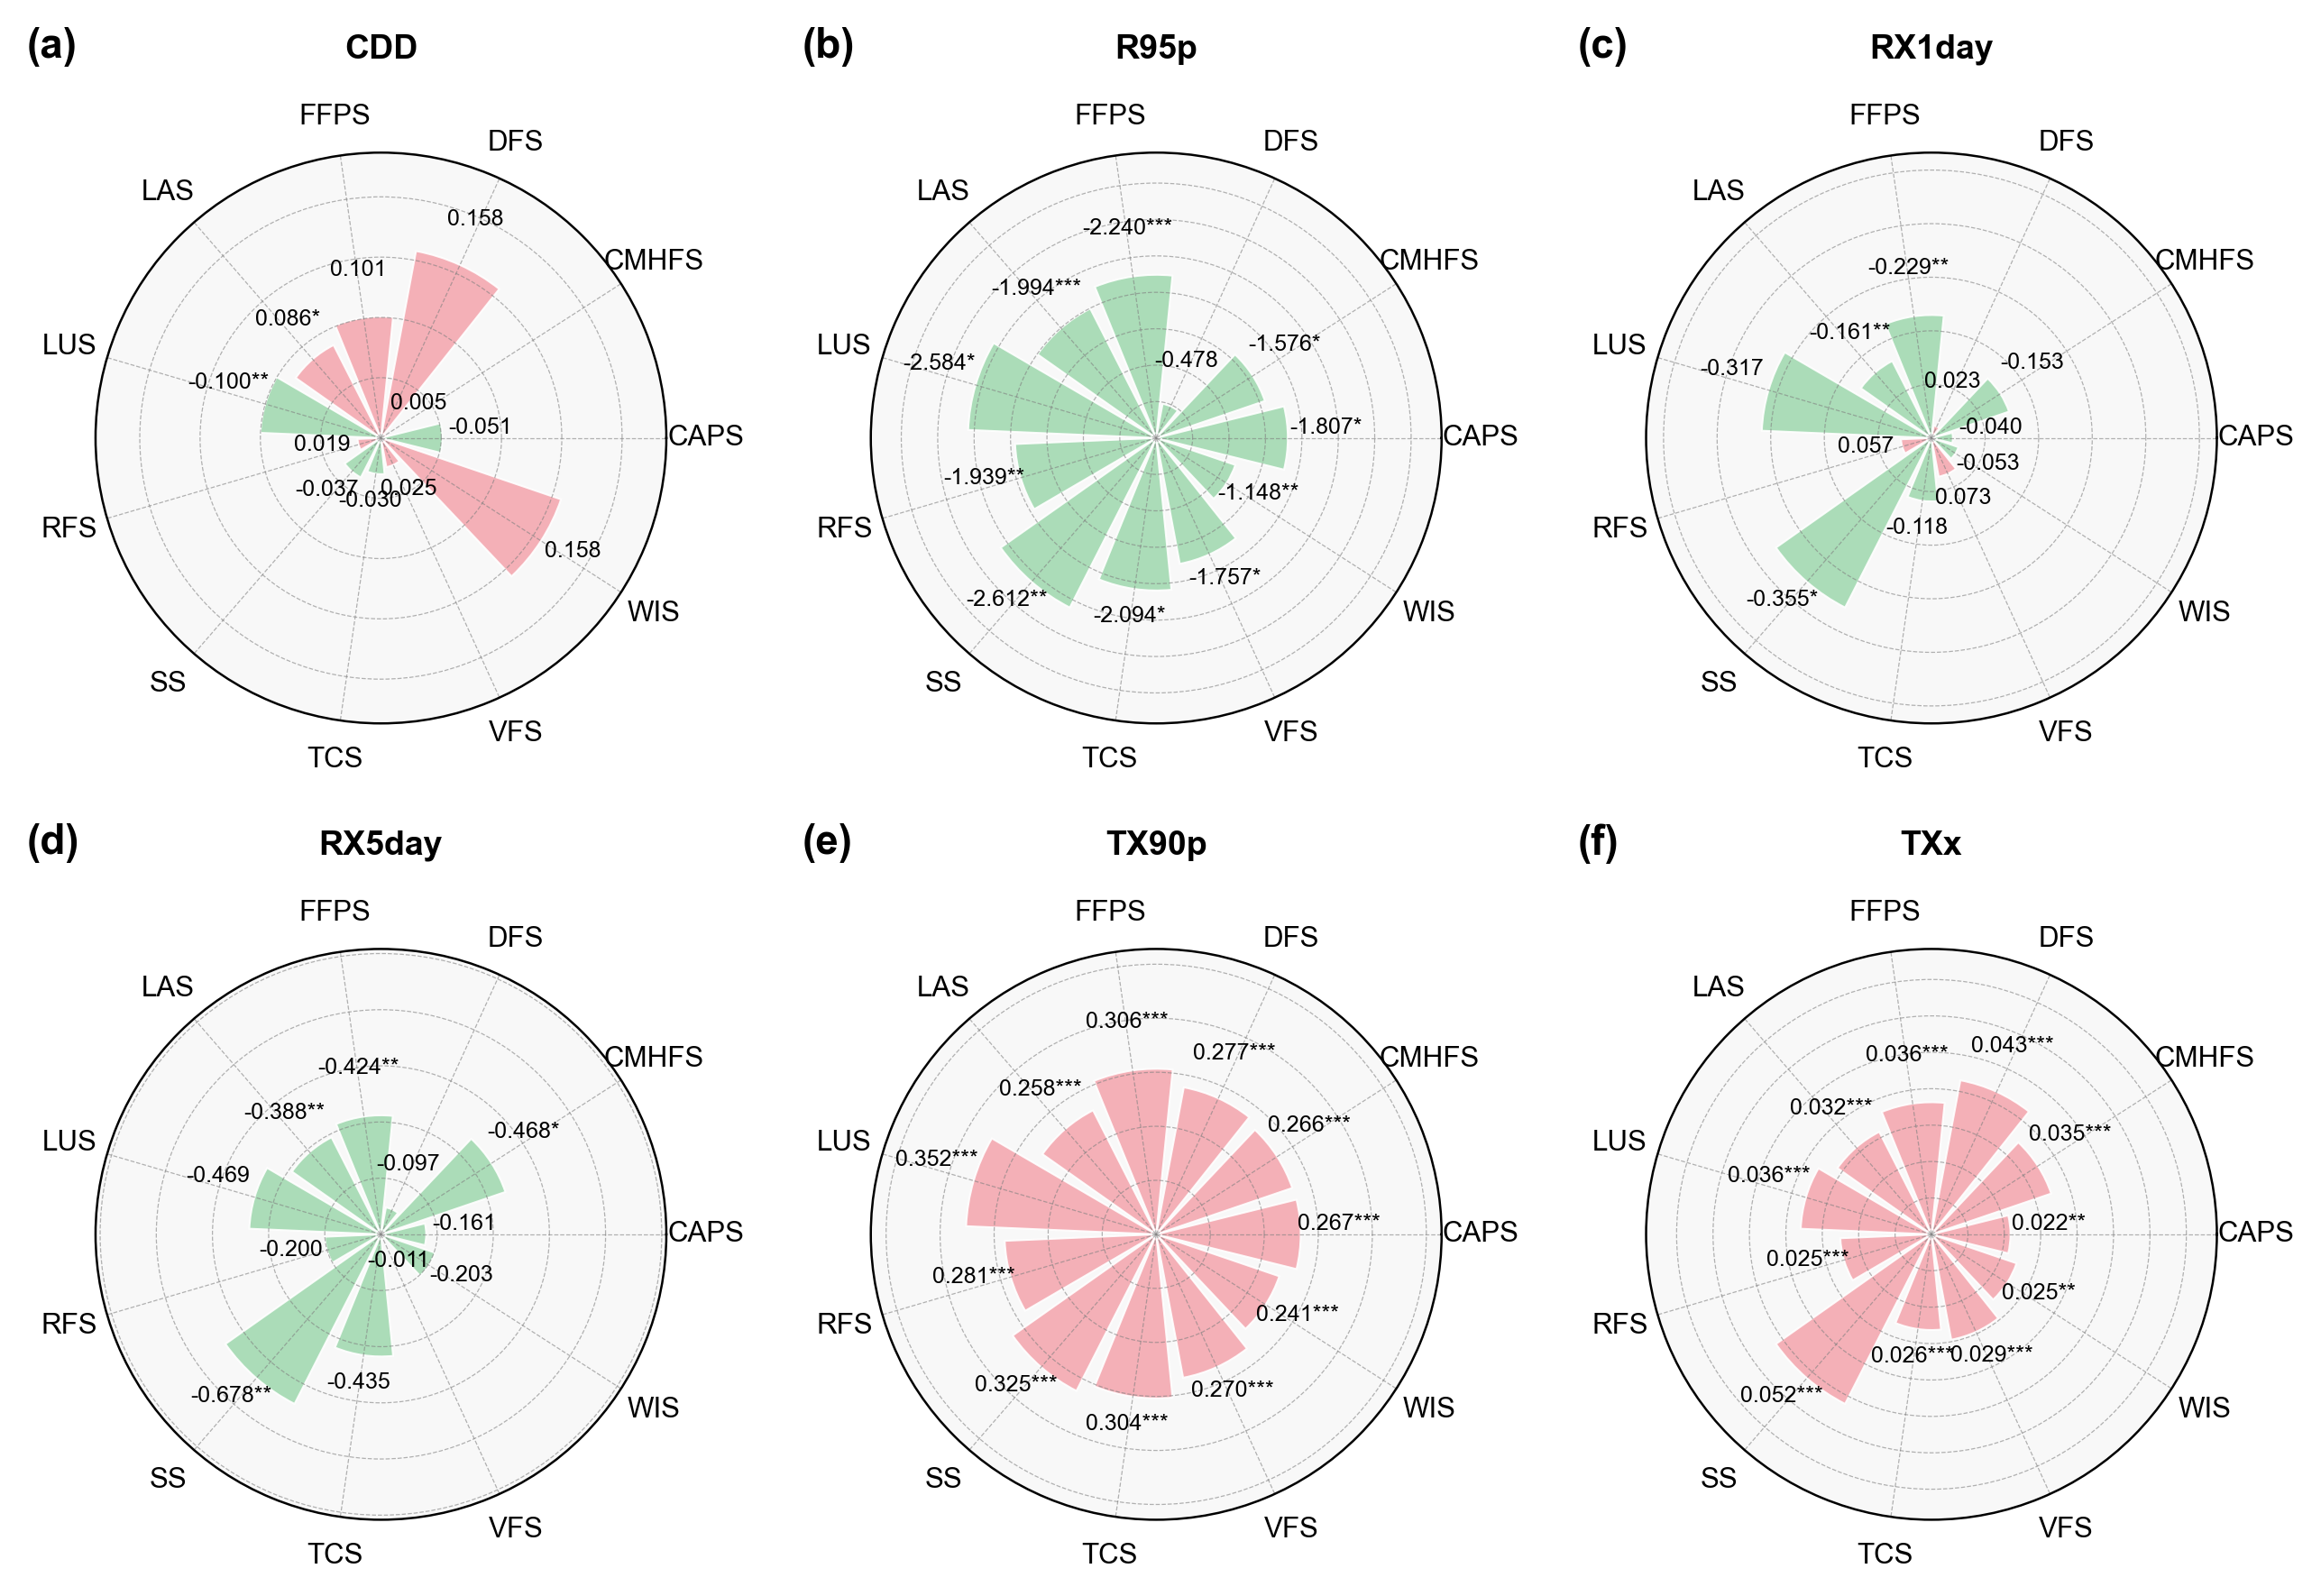

玫瑰图组图已保存至: C:\Users\28550\Desktop\Results\Figure3\type_trend_rose.png


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pymannkendall as mk

# ========== File paths ==========
data_path = r"C:\Users\*****\Desktop\Results\Figure3\type_annual_mean_1980_2020.csv"
output_fig = r"C:\Users\*****\Desktop\Results\Figure3\type_trend_rose.png"

# ========== Read data ==========
df = pd.read_csv(data_path)

id_vars = ["Type", "Indicator"]
year_cols = [c for c in df.columns if c not in id_vars]
df_long = df.melt(id_vars=id_vars, var_name="Year", value_name="Value")
df_long["Year"] = df_long["Year"].astype(int)
df_long = df_long.sort_values(["Indicator", "Type", "Year"])

# ========== Sen's slope and MK test ==========
def calc_trend(series):
    clean = series.dropna().values
    if len(clean) < 4:
        return np.nan, np.nan, np.nan, ''
    res = mk.original_test(clean)
    slope, z, p = res.slope, res.z, res.p
    if p <= 0.01:    sig = '***'
    elif p <= 0.05:  sig = '**'
    elif p <= 0.1:   sig = '*'
    else:            sig = ''
    return slope, z, p, sig

trend_data = []
indicators = ["CDD", "R95p", "RX1day", "RX5day", "TX90p", "TXx"]
for ind in indicators:
    sub = df_long[df_long["Indicator"] == ind]
    for ty in sorted(sub["Type"].unique()):
        series = sub[sub["Type"] == ty].groupby("Year")["Value"].mean()
        slope, z, p, sig = calc_trend(series)
        trend_data.append({
            "Indicator": ind,
            "Type": ty,
            "Slope": slope,
            "Z": z,
            "Sig": sig
        })

trend_df = pd.DataFrame(trend_data)
types_all = sorted(trend_df["Type"].unique())

# ========== Plot settings ==========
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 8,
    'axes.linewidth': 0.6,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Arial',
    'mathtext.it': 'Arial:italic',
    'mathtext.bf': 'Arial:bold',
})

color_pos = '#F4A8B0'
color_neg = '#A3D9B1'

fig, axes = plt.subplots(2, 3, subplot_kw=dict(polar=True),
                         figsize=(9.0, 6.5), dpi=300)
axes = axes.flatten()

theta = np.linspace(0.0, 2 * np.pi, len(types_all), endpoint=False)
width = 2 * np.pi / len(types_all) * 0.85

for i, ind in enumerate(indicators):
    ax = axes[i]
    sub = trend_df[trend_df["Indicator"] == ind].set_index("Type").reindex(types_all)
    slopes = sub["Slope"].values
    sigs = sub["Sig"].values

    # Calculate the maximum absolute value for this subplot (used to set range and offset)
    max_slope = max(abs(s) for s in slopes if not np.isnan(s)) if sub["Slope"].notna().any() else 1
    offset = max_slope * 0.2          # Outward offset
    ax.set_ylim(0, max_slope * 1.5)  # Leave room for annotations

    # Add light gray background (fill the entire polar area)
    ax.set_facecolor('#F8F8F8')

    for j, ty in enumerate(types_all):
        slope = slopes[j]
        sig = sigs[j]
        angle = theta[j]

        if np.isnan(slope):
            continue

        abs_slope = abs(slope)
        bar_color = color_pos if slope >= 0 else color_neg
        ax.bar(angle, abs_slope, width=width, bottom=0,
               color=bar_color, edgecolor='white', linewidth=0.5, alpha=0.9)

        label_text = f"{slope:.3f}"
        if sig:
            label_text += sig
        ax.annotate(label_text,
                    xy=(angle, abs_slope + offset),
                    ha='center', va='bottom',
                    fontsize=6, color='black')

    ax.set_xticks(theta)
    ax.set_xticklabels(types_all, fontsize=7.5)

    # Hide radial tick labels
    ax.set_yticklabels([])

    ax.spines['polar'].set_visible(True)
    ax.spines['polar'].set_linewidth(0.6)

    ax.grid(color='gray', linestyle='--', linewidth=0.3, alpha=0.6)

    ax.set_title(ind, fontsize=9, weight='bold', pad=12)

    # ===== Add subplot labels (a)~(f) =====
    ax.text(-0.12, 1.22, f"({chr(97 + i)})", transform=ax.transAxes,
            fontsize=11, fontweight='bold', va='top', ha='left')

for j in range(len(indicators), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout(pad=2.0, rect=[0.02, 0.02, 1, 0.96])
plt.savefig(output_fig, bbox_inches='tight', dpi=600, facecolor='white')
plt.show()

print(f"Rose diagram panel saved to: {output_fig}")